# Density Based Clustering

**Authors:** Abderrahmane Salmi, Ricardo Talarico, Lorenzo Allegrini

## Imports

In [12]:
import numpy as np
import pandas as pd
import math
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [13]:
tracks_df = pd.read_csv("../datasets/tracks_cleaned.csv")
artists_df = pd.read_csv("../datasets/artists_cleaned.csv")

## Features Selection

In [36]:
selected_features = [
    # linguistic / lyrics
    # 'n_tokens',
    # 'swear_IT',
    # 'lexical_density',

    # audio features
    # 'bpm',
    'centroid',
    'loudness',
    'spectral_complexity',
    # 'flux',
    'rolloff',

    # popularity
    'popularity',
    # 'relative_popularity',

    # time-related
    # 'season_autumn', 'season_spring', 'season_summer', 'season_winter',

    # engineered features
    'has_collaboration',
    'aggressiveness',
    # 'song_age',
    # 'duration_sec'
]

In [37]:
#Extract feature matrix
X = tracks_df[selected_features].copy()

## Preprocessing (Scaling & Normalization)

In [38]:
# Check for NaN values
print(X.isna().sum())

centroid               0
loudness               0
spectral_complexity    0
rolloff                0
popularity             0
has_collaboration      0
aggressiveness         0
dtype: int64


**log1p transformation**: applying log to numeric skewed features

In [39]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric features for clustering
numeric_features = X.columns.tolist()  # X is our selected features for clustering

# Step 0: Filter out binary and one-hot encoded features (only keep features with >2 unique values)
continuous_features = [col for col in numeric_features if X[col].nunique() > 2]

# Step 1: Compute skewness
skewness = X[continuous_features].skew().sort_values(ascending=False)
print("Skewness of continuous features:\n", skewness)

# Step 2: Plot distribution of highly skewed features (optional)
high_skew = skewness[skewness > 2].index  # threshold for positive skew
# for col in high_skew:
#     plt.figure()
#     sns.histplot(X[col], kde=True)
#     plt.title(f'Distribution of {col} (skew={skewness[col]:.2f})')
#     plt.show()

# Step 3: Apply log1p transformation to highly skewed continuous features
for col in high_skew:
    # Only apply if all values are >= 0 (log1p cannot handle negative values)
    if (X[col] >= 0).all():
        X[col] = np.log1p(X[col])
    else:
        print(f"Skipping {col} because it has negative values.")

# Step 4: Verify the new skewness
new_skewness = X[continuous_features].skew().sort_values(ascending=False)
print("Skewness after log1p transformation:\n", new_skewness)

Skewness of continuous features:
 popularity             0.260412
centroid               0.181541
spectral_complexity    0.099082
aggressiveness        -0.053941
rolloff               -0.060360
loudness              -0.153119
dtype: float64
Skewness after log1p transformation:
 popularity             0.260412
centroid               0.181541
spectral_complexity    0.099082
aggressiveness        -0.053941
rolloff               -0.060360
loudness              -0.153119
dtype: float64


**Normalization**: We tried to normalize using both z-score and min-max, to see which one works best for different algorithms.

In [40]:
# Scale the features (z-score)
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
X_zscore = std_scaler.fit_transform(X)

In [41]:
# Scale the features (Min-Max)
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)

In [42]:
X_scaled = X_minmax

## DBScan

### Study of Clustering Parameters

In DBSCAN, we have to choose two parameters:

* **eps:** The maximum distance between two samples for one to be considered as in the neighborhood of the other.

* **min_samples:** The number of samples (or total weight) in a neighborhood for a point to be considered as a core point.

In [43]:
min_samples_grid = np.arange(len(selected_features), 2 * len(selected_features))
eps_grid = np.round(np.linspace(0.07, 0.2, 12), 2)
print("Parameters for the grid search:\nmin_samples: {0}\neps: {1}".format(min_samples_grid, eps_grid))

Parameters for the grid search:
min_samples: [ 7  8  9 10 11 12 13]
eps: [0.07 0.08 0.09 0.11 0.12 0.13 0.14 0.15 0.16 0.18 0.19 0.2 ]


In [45]:
def generate_min_samples_range(D, num_steps):
    """
    Generates a range of min_samples values centered around 2*D.
    D: Number of dimensions (features).
    num_steps: The desired total number of values in the output list.
    """
    # Heuristic center point
    center = 2 * D
    
    # Calculate the span (e.g., 5 steps above and below the center)
    span = max(D // 2, 5) 
    
    start = max(5, center - span) # min_samples should be >= 5
    end = center + span + 1
    
    # Generate num_steps points evenly spaced within [start, end]
    min_samples_range = np.linspace(start, end, num_steps, dtype=int)
    
    # Ensure all generated values are unique and greater than 4
    return np.unique(min_samples_range[min_samples_range >= 5]).tolist()

def generate_eps_range(knee_value, range_width, num_steps):
    """
    Generates a range of eps values centered around the knee_value.
    knee_value: The estimated epsilon from the K-Distance graph.
    range_width: The total span of the search (e.g., 0.8 means [knee-0.4, knee+0.4]).
    num_steps: The desired total number of values in the output array.
    """
    start = knee_value - (range_width / 2)
    end = knee_value + (range_width / 2)
    
    # Ensure start is not negative
    start = max(0.1, start)
    
    # Generate num_steps points evenly spaced within [start, end]
    eps_range = np.linspace(start, end, num_steps)
    
    # Round to 2 decimal places for cleaner Grid Search values
    return np.round(eps_range, 2).tolist()

In [47]:
min_samples_range = generate_min_samples_range(len(selected_features), 5)
eps_range = generate_eps_range(0.15, 0.05, 10)
print("Parameters for the grid search:\nmin_samples: {0}\neps: {1}".format(min_samples_range, eps_range))

Parameters for the grid search:
min_samples: [9, 11, 14, 17, 20]
eps: [0.12, 0.13, 0.14, 0.14, 0.15, 0.15, 0.16, 0.16, 0.17, 0.18]


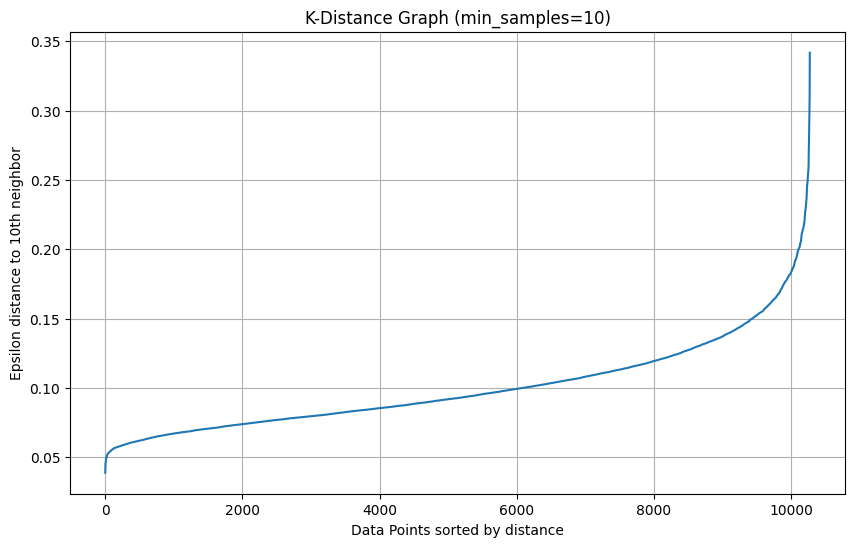

In [26]:
# 1. Select min_samples
min_samples = 2 * len(selected_features)  # Rule of thumb: 2 * len(features)

# 2. Calculate distance to the kth nearest neighbor
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# 3. Sort distances (we only care about the distance to the min_samples-th neighbor)
distances = np.sort(distances[:, min_samples-1], axis=0)

# 4. Plot the k-distance Graph
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title(f'K-Distance Graph (min_samples={min_samples})')
plt.xlabel('Data Points sorted by distance')
plt.ylabel(f'Epsilon distance to {min_samples}th neighbor')
plt.grid(True)
plt.show()

In [48]:
# --- STEP 2: Grid Search ---

# Define ranges to test
# Eps: 0.5 to 2.5 (based on standard scale)
# eps_values = [0.07, 0.09, 0.11, 0.13, 0.15, 0.16, 0.17, 0.18, 0.19]
eps_values = eps_range
# Min_samples: varied around 2*features
# min_samples_values = [5, 7, 10, 13, 15, 20]
min_samples_values = min_samples_range

results = []

print(f"Starting Grid Search with {len(eps_values) * len(min_samples_values)} combinations...")

for eps in eps_values:
    for min_samples in min_samples_values:
        
        # Run DBSCAN
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        
        # Count clusters (ignoring noise -1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_ratio = n_noise / len(labels)
        
        # We only care if we found at least 2 clusters and not everything is noise
        if n_clusters > 1 and noise_ratio < 0.9:
            # Silhouette Score (measures how well separated clusters are)
            # We use a sample if dataset is huge, but 11k is manageable for full calc
            sil_score = silhouette_score(X_scaled, labels)
            
            results.append({
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'noise_ratio': noise_ratio,
                'silhouette': sil_score
            })
            
# Create a DataFrame of results
results_df = pd.DataFrame(results)

# Sort by best Silhouette Score
print("Top 5 Parameter Combinations:")
print(results_df.sort_values(by='silhouette', ascending=False).head(5))

Starting Grid Search with 50 combinations...
Top 5 Parameter Combinations:
     eps  min_samples  n_clusters  noise_ratio  silhouette
45  0.18            9           2     0.054030    0.408893
46  0.18           11           2     0.063279    0.402784
47  0.18           14           2     0.077395    0.394489
40  0.17            9           2     0.078758    0.389181
48  0.18           17           2     0.092484    0.382774


In [50]:
# --- STEP 3: Heatmap Visualization ---

# Pivot table for the heatmap
pivot_table = results_df.pivot(index='min_samples', columns='eps', values='silhouette')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, annot=True, cmap='viridis', fmt=".2f")
plt.title('DBSCAN Silhouette Score for Parameter Combinations')
plt.show()

ValueError: Index contains duplicate entries, cannot reshape

In [31]:
results_df_copy = results_df

In [51]:
# Pivot tables for heatmaps
df_clusters_grid = results_df.pivot(index='eps', columns='min_samples', values='n_clusters')
df_sil_grid      = results_df.pivot(index='eps', columns='min_samples', values='silhouette')

# Convert cluster grid to integers (silhouette stays float)
df_clusters_grid_int = df_clusters_grid.fillna(0).astype(int)

fig, axs = plt.subplots(1, 2, figsize=(22, 8))

# --- Heatmap 1: Number of Clusters ---
sns.heatmap(
    df_clusters_grid_int,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    cbar=False,
    ax=axs[0]
)
axs[0].set_title("Number of Clusters")
axs[0].set_xlabel("min_samples")
axs[0].set_ylabel("epsilon")

# --- Heatmap 2: Silhouette Score ---
sns.heatmap(
    df_sil_grid,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    cbar=False,
    ax=axs[1]
)
axs[1].set_title("Silhouette Score")
axs[1].set_xlabel("min_samples")
axs[1].set_ylabel("epsilon")

plt.tight_layout()
plt.show()


ValueError: Index contains duplicate entries, cannot reshape

In [58]:
# Filter results to only those with at least 2 clusters
valid_results = results_df[results_df['n_clusters'] >= 2]

if valid_results.empty:
    print("No valid parameter combinations found with n_clusters >= 2.")
else:
    # Pick combination with highest silhouette score
    best_row = valid_results.sort_values(by='silhouette', ascending=False).iloc[0]

    print("\nBest Parameters Found (n_clusters > 2):")
    print(f"eps = {best_row['eps']}")
    print(f"min_samples = {best_row['min_samples']}")
    print(f"n_clusters = {best_row['n_clusters']}")
    print(f"noise_ratio = {best_row['noise_ratio']:.2%}")
    print(f"silhouette_score = {best_row['silhouette']:.4f}")



Best Parameters Found (n_clusters > 2):
eps = 0.18
min_samples = 9.0
n_clusters = 2.0
noise_ratio = 5.40%
silhouette_score = 0.4089


In [57]:
# --- PARAMETERS ---
best_eps = 0.18
best_min_samples = 9

# --- RUN DBSCAN ---
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels = dbscan.fit_predict(X_scaled)

# Add labels to dataframe
X['dbscan_cluster'] = labels

# Count clusters
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

# compute silhouette score
silhouette = silhouette_score(X_scaled, labels)

print(f'DBSCAN (eps={best_eps}, min_samples={best_min_samples})')
print(f'Number of labels: {len(set(labels))}')
print(f'Estimated number of clusters: {n_clusters_}')
print(f'Estimated number of noise points: {n_noise_}')
print(f'Noise ratio: {n_noise_ / len(labels):.2%}')
print(f'Silhouette Score: {silhouette:.4f}')

# Print count of each label
print("\nCounts per label:")
print(pd.Series(labels).value_counts().sort_index())


DBSCAN (eps=0.18, min_samples=9)
Number of labels: 3
Estimated number of clusters: 2
Estimated number of noise points: 555
Noise ratio: 5.40%
Silhouette Score: 0.4089

Counts per label:
-1     555
 0    3097
 1    6620
Name: count, dtype: int64
